<a href="https://colab.research.google.com/github/ziadm8692-glitch/Data-Analysis-Portfolio/blob/main/Finance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_excel("/content/finance-loans.xlsx")

In [ ]:
df.head(5)

,application_id,application_date,age,employment_type,annual_income,loan_amount,loan_term_months,interest_rate,credit_score,existing_debts,purpose,region,approved,defaulted
0,L00001,2024-08-05,33,Self-Employed,278405,125120,36,8.7,509,38851,Home,Cairo,No,NaN
1,L00002,2025-03-08,49,Salaried,221469,259254,12,8.1,534,86539,Business,Cairo,No,NaN
2,L00003,2025-02-18,48,Salaried,132701,239456,84,12.9,700,0,Business,Alexandria,Yes,No
3,L00004,2025-03-18,47,Business Owner,412996,226403,60,8.0,772,101828,Car,Cairo,Yes,No
4,L00005,2024-07-04,25,Salaried,186087,77934,84,11.3,730,0,Home,Upper Egypt,Yes,No


# ***Cleaning Data***

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
application_id,0
application_date,0
age,0
employment_type,0
annual_income,0
loan_amount,0
loan_term_months,0
interest_rate,0
credit_score,0
existing_debts,0


In [ ]:
# حساب القيمة الأكثر تكراراً
most_frequent = df['defaulted'].mode()[0]

# ملء الفراغات بها
df['defaulted'] = df['defaulted'].fillna(most_frequent)

In [ ]:
df.isnull().sum()

,0
application_id,0
application_date,0
age,0
employment_type,0
annual_income,0
loan_amount,0
loan_term_months,0
interest_rate,0
credit_score,0
existing_debts,0


In [ ]:
df.head(5)

,application_id,application_date,age,employment_type,annual_income,loan_amount,loan_term_months,interest_rate,credit_score,existing_debts,purpose,region,approved,defaulted
0,L00001,2024-08-05,33,Self-Employed,278405,125120,36,8.7,509,38851,Home,Cairo,No,No
1,L00002,2025-03-08,49,Salaried,221469,259254,12,8.1,534,86539,Business,Cairo,No,No
2,L00003,2025-02-18,48,Salaried,132701,239456,84,12.9,700,0,Business,Alexandria,Yes,No
3,L00004,2025-03-18,47,Business Owner,412996,226403,60,8.0,772,101828,Car,Cairo,Yes,No
4,L00005,2024-07-04,25,Salaried,186087,77934,84,11.3,730,0,Home,Upper Egypt,Yes,No


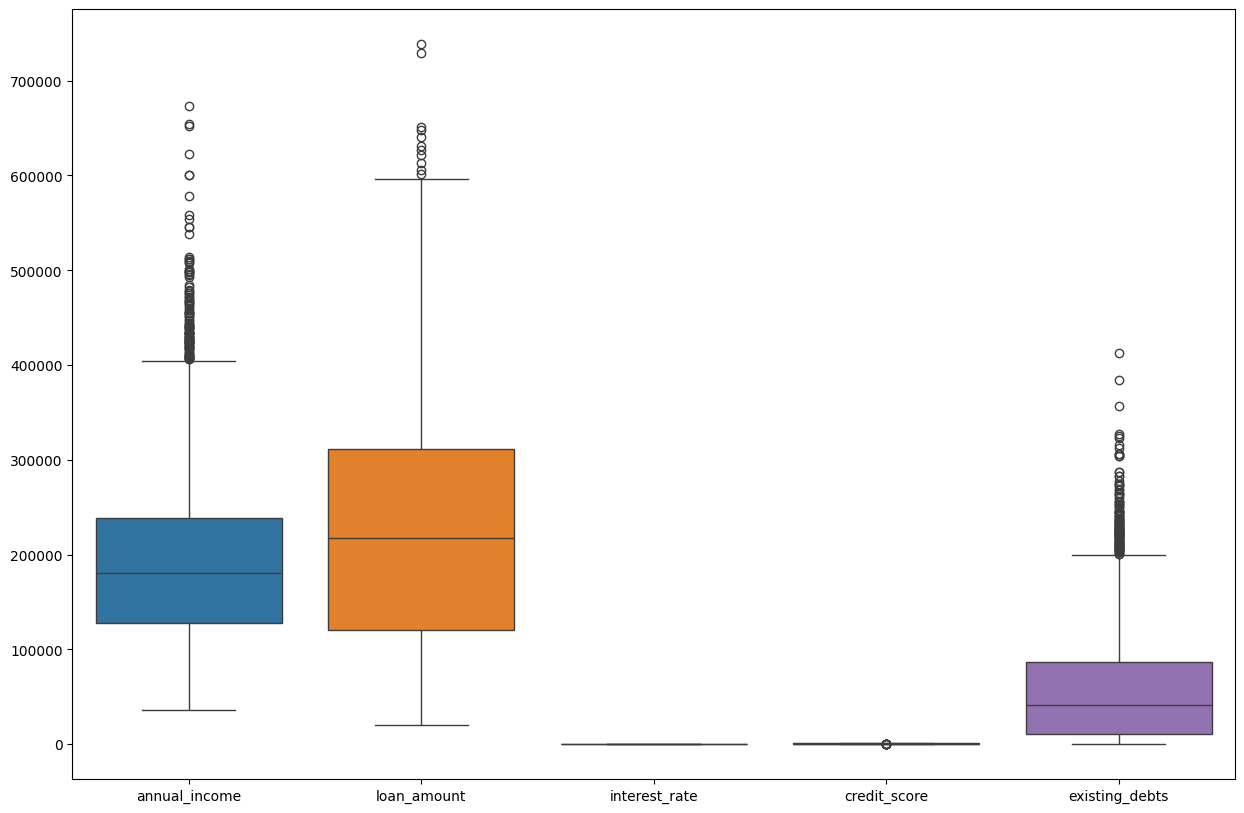

In [ ]:
plt.figure(figsize=(15,10))
sns.boxplot(df[['annual_income','loan_amount','interest_rate','credit_score','existing_debts']])
plt.show()

In [ ]:
Q1=df[['annual_income','loan_amount','interest_rate','credit_score','existing_debts']].quantile(0.25)
Q3=df[['annual_income','loan_amount','interest_rate','credit_score','existing_debts']].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
df[['annual_income','loan_amount','interest_rate','credit_score','existing_debts']]=df[['annual_income','loan_amount','interest_rate','credit_score','existing_debts']].clip(lower,upper, axis=1)

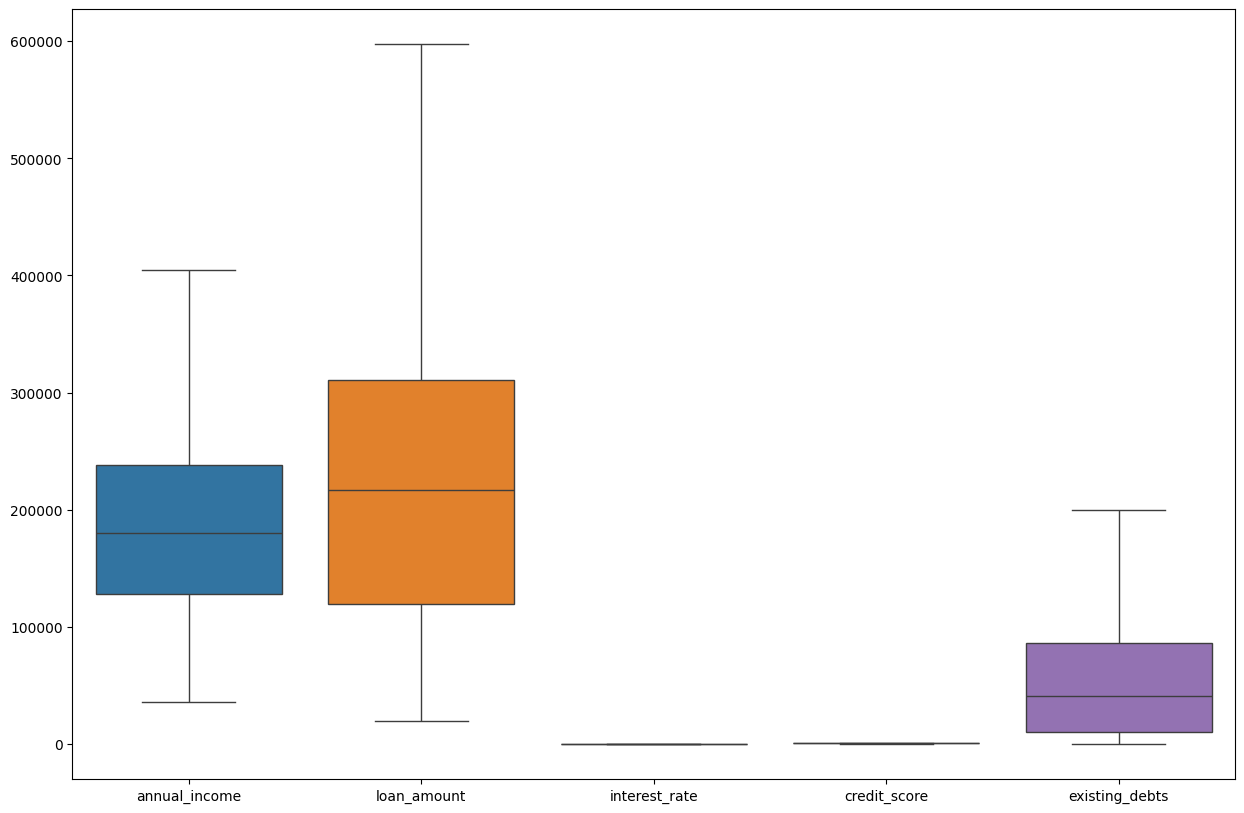

In [ ]:
plt.figure(figsize=(15,10))
sns.boxplot(df[['annual_income','loan_amount','interest_rate','credit_score','existing_debts']])
plt.show()

In [ ]:
df.dtypes

,0
application_id,object
application_date,object
age,int64
employment_type,object
annual_income,float64
loan_amount,float64
loan_term_months,int64
interest_rate,float64
credit_score,float64
existing_debts,float64


In [ ]:
df['application_date']=pd.to_datetime(df['application_date'])

In [ ]:
df.dtypes

,0
application_id,object
application_date,datetime64[ns]
age,int64
employment_type,object
annual_income,float64
loan_amount,float64
loan_term_months,int64
interest_rate,float64
credit_score,float64
existing_debts,float64


In [ ]:
df.isnull().sum()

,0
application_id,0
application_date,0
age,0
employment_type,0
annual_income,0
loan_amount,0
loan_term_months,0
interest_rate,0
credit_score,0
existing_debts,0


In [ ]:
df['Year']=df['application_date'].dt.year

In [ ]:
df['Month']=df['application_date'].dt.month

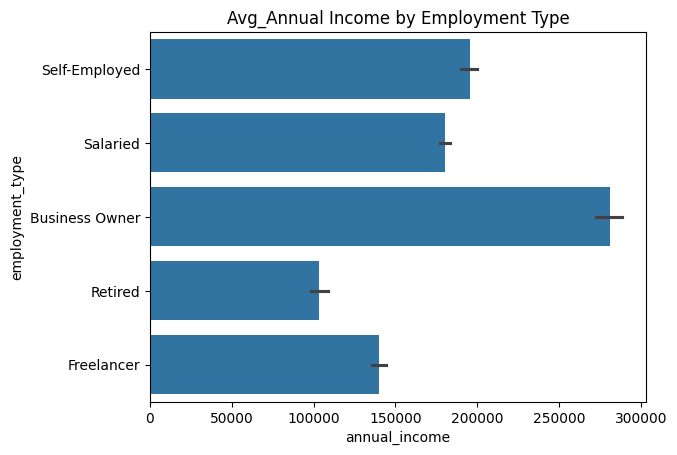

In [ ]:
sns.barplot(data=df,x='annual_income',y='employment_type')
plt.title('Avg_Annual Income by Employment Type')
plt.show()

In [ ]:

def get_age_group(age):
    if 21 <= age <= 30:
        return '21-30'
    elif 31 <= age <= 40:
        return '31-40'
    elif 41 <= age <= 50:
        return '41-50'
    elif 51 <= age <= 60:
        return '51-60'
    elif 61 <= age <= 71:
        return '61-71'
    else:
        return 'Out of range'


df['Age_Group'] = df['age'].apply(get_age_group)

In [ ]:
df['Age_Group']

,Age_Group
0,31-40
1,41-50
2,41-50
3,41-50
4,21-30
...,...
3995,Out of range
3996,41-50
3997,41-50
3998,51-60


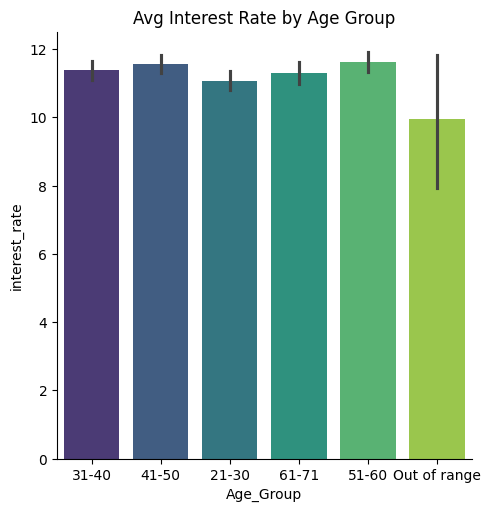

In [ ]:
sns.catplot(x='Age_Group',y='interest_rate',data=df,kind='bar',palette='viridis', hue='Age_Group', legend=False)
plt.title('Avg Interest Rate by Age Group')
plt.show()

/tmp/ipykernel_2471/583374933.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='purpose', y='loan_amount', data=df, palette='magma')


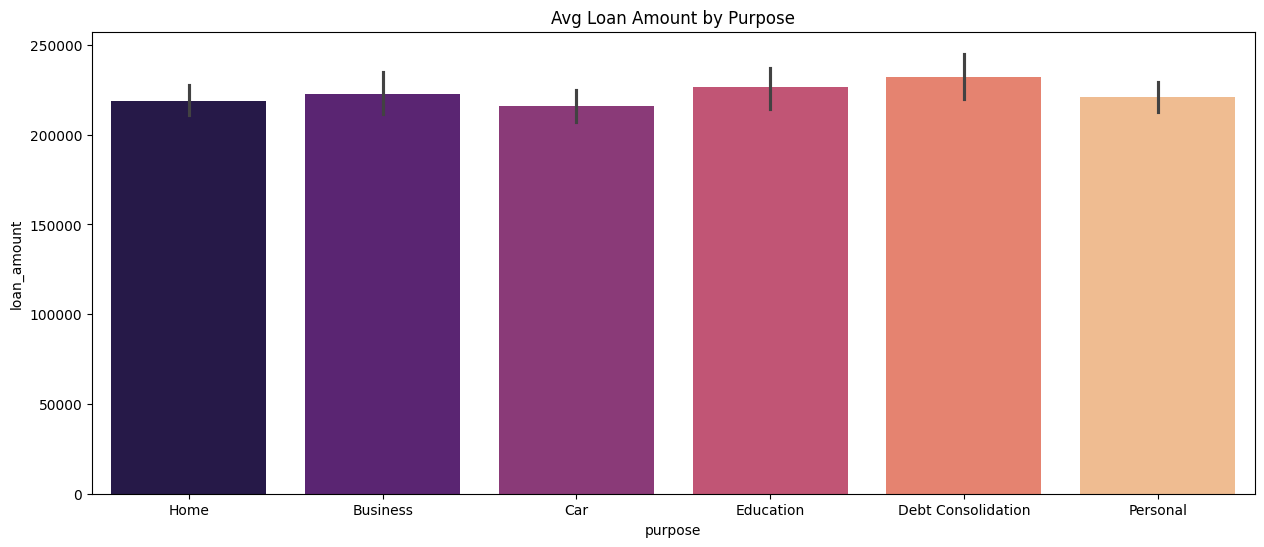

In [ ]:
plt.figure(figsize=(15,6))
sns.barplot(x='purpose', y='loan_amount', data=df, palette='magma')
plt.title('Avg Loan Amount by Purpose')
plt.show()

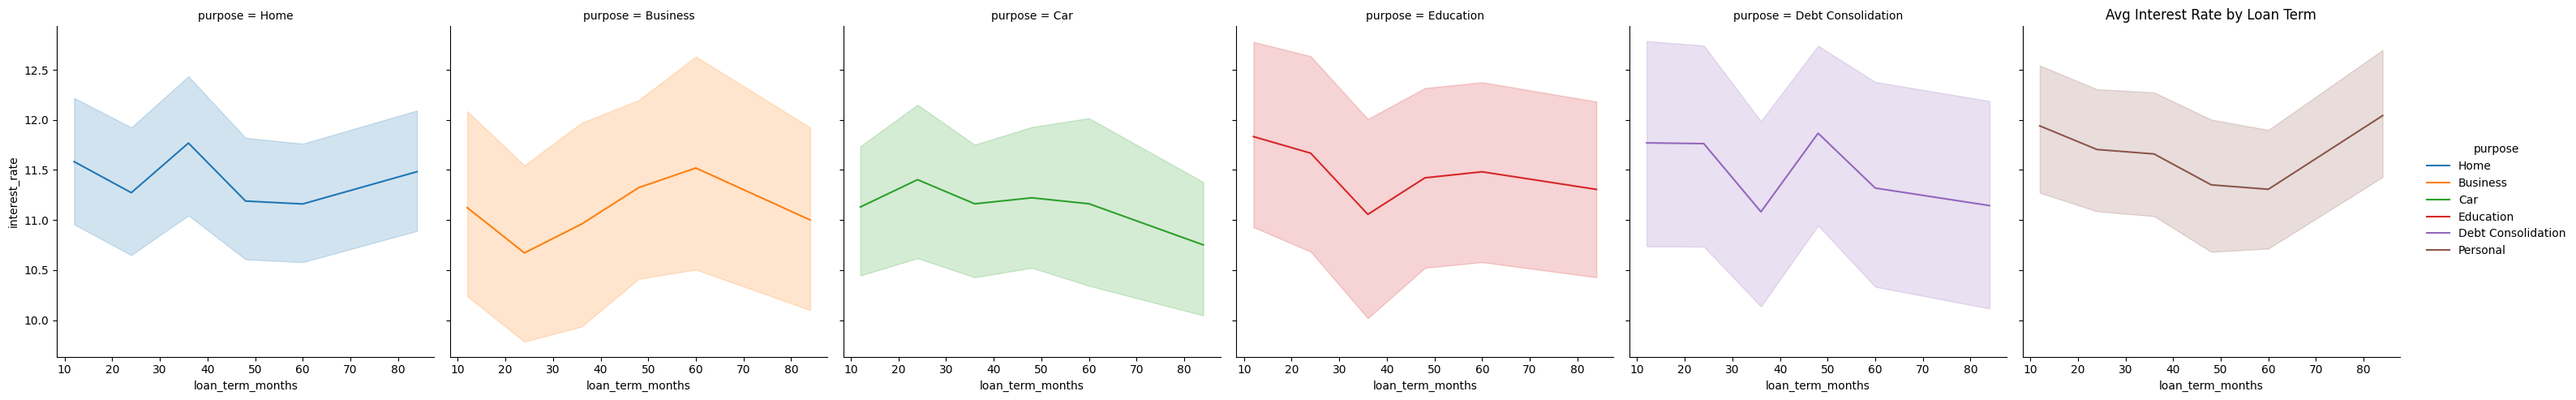

In [ ]:
sns.relplot(x='loan_term_months',y='interest_rate',data=df,kind='line',hue='purpose',col='purpose')
plt.title('Avg Interest Rate by Loan Term')
plt.show()

<Figure size 3000x1000 with 0 Axes>

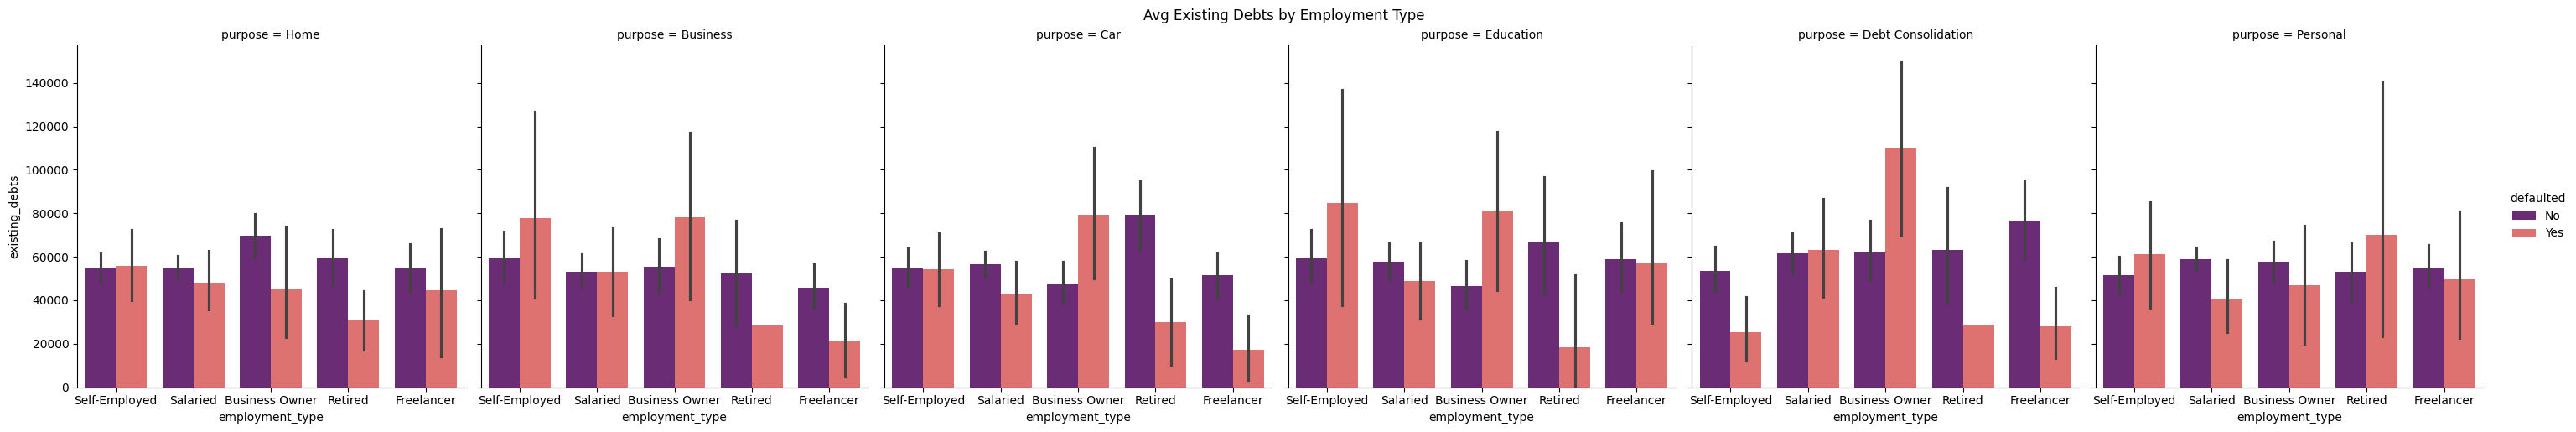

In [ ]:
plt.figure(figsize=(30,10))
sns.catplot(x='employment_type',y='existing_debts',data=df,hue='defaulted',palette='magma',col='purpose', kind='bar')
plt.suptitle('Avg Existing Debts by Employment Type', y=1.02)
plt.show()

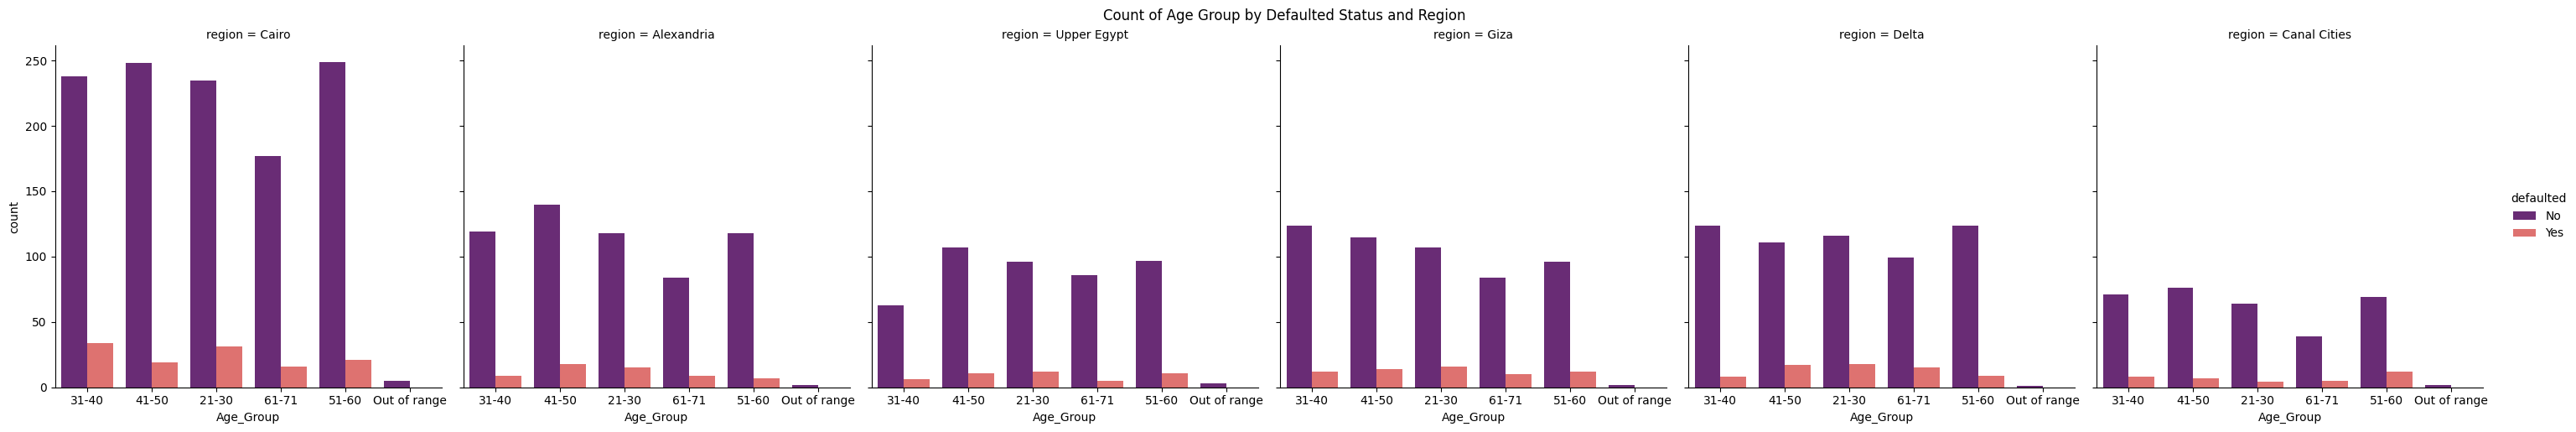

In [ ]:

sns.catplot(x='Age_Group',data=df,palette='magma',kind='count',hue='defaulted',col='region')
plt.suptitle('Count of Age Group by Defaulted Status and Region', y=1.02)
plt.show()

/tmp/ipykernel_2471/4040869081.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df['defaulted'],palette='Set2')


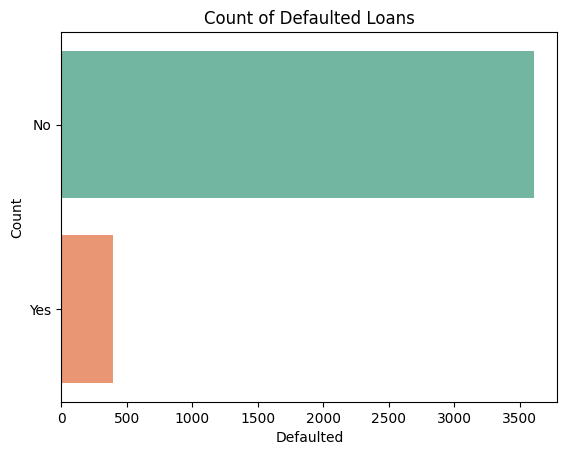

In [ ]:
sns.countplot(df['defaulted'],palette='Set2')
plt.xlabel('Defaulted')
plt.ylabel('Count')
plt.title('Count of Defaulted Loans')
plt.show()